# Bone marrow integration with standard scVI (default hyperparameters)

This notebook uses standard `scvi.model.SCVI` with all default hyperparameters (`n_hidden=128`, `n_latent=10`, `n_layers=1`, `gene_likelihood="zinb"`, `dispersion="gene"`).

Compare with:
- [bone_marrow_tutorial.ipynb](bone_marrow_tutorial.ipynb) — regularizedvi default (NB + Exp on $\sqrt{\theta}$)
- [bone_marrow_gamma_poisson.ipynb](bone_marrow_gamma_poisson.ipynb) — regularizedvi GammaPoisson mode
- [bone_marrow_scvi_custom.ipynb](bone_marrow_scvi_custom.ipynb) — standard scVI with same architecture

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy
import torch
from pyro.distributions import constraints
from pyro.distributions.transforms import SoftplusTransform
from torch.distributions import biject_to, transform_to

import scvi


# Replace default exp positive transform with softplus (numerically more stable)
@biject_to.register(constraints.positive)
@transform_to.register(constraints.positive)
def _transform_to_positive(constraint):
    return SoftplusTransform()


# Use high-precision matmul for better numerical stability on GPU
torch.set_float32_matmul_precision("high")

rcParams["pdf.fonttype"] = 42  # enables correct plotting of text for publication figures

## 1. Load data

Load the bone marrow multiome dataset and extract the GEX (gene expression) modality.

In [ ]:
import os

from regularizedvi.utils import download_bone_marrow_dataset

results_folder = "results/scvi_default/"
os.makedirs(results_folder, exist_ok=True)

h5ad_path = download_bone_marrow_dataset(data_folder="data/")
adata = sc.read_h5ad(h5ad_path)

# Extract gene expression only
adata = adata[:, adata.var["feature_types"] == "GEX"].copy()
adata.var["SYMBOL"] = adata.var_names.values.copy()
adata.var_names = adata.var["gene_ids"].values.astype(str).copy()
adata.X = adata.layers["counts"]

print(adata)
print(f"\nBatches: {adata.obs['batch'].nunique()}")
print(f"Sites: {adata.obs['site'].nunique()}")
print(f"Donors: {adata.obs['donor'].nunique()}")

## 2. Quality control

In [3]:
# Batch and cell type composition
for c in ["batch", "site", "donor", "l2_cell_type"]:
    print(adata.obs[c].value_counts())
    print()

batch
s4d8     9876
s4d1     8023
s3d10    6780
s1d2     6740
s1d1     6224
s2d4     6111
s2d5     4895
s3d3     4325
s4d9     4325
s1d3     4279
s2d1     4220
s3d7     1770
s3d6     1679
Name: count, dtype: int64

site
site4    22224
site1    17243
site2    15226
site3    14554
Name: count, dtype: int64

donor
donor1     18467
donor8      9876
donor3      8604
donor10     6780
donor2      6740
donor4      6111
donor5      4895
donor9      4325
donor7      1770
donor6      1679
Name: count, dtype: int64

l2_cell_type
CD8+ T activated    11589
CD14+ Mono          10842
NK                   6929
CD4+ T activated     5526
Naive CD20+ B        5052
Erythroblast         4916
CD4+ T naive         4398
Transitional B       2810
Proerythroblast      2300
CD16+ Mono           1894
B1 B                 1890
Normoblast           1780
Early Lymphoid       1779
G/M prog             1203
pDC                  1191
HSC                  1072
CD8+ T naive         1012
MK/E prog             884
cDC2     

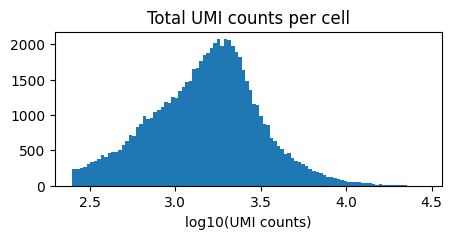

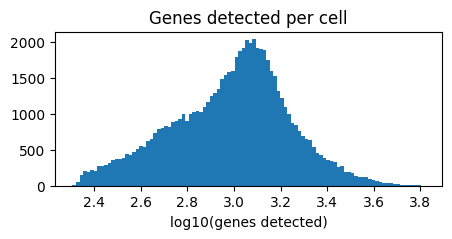

In [4]:
# QC distributions
rcParams["figure.figsize"] = 5, 2
plt.hist(np.log10(adata.obs["GEX_n_counts"]), bins=100)
plt.xlabel("log10(UMI counts)")
plt.title("Total UMI counts per cell")
plt.show()

plt.hist(np.log10(adata.obs["GEX_n_genes"]), bins=100)
plt.xlabel("log10(genes detected)")
plt.title("Genes detected per cell")
plt.show()

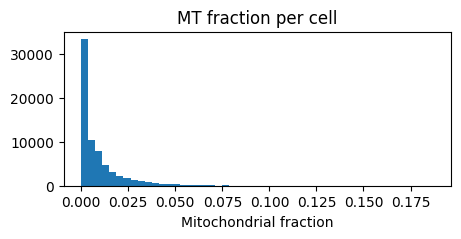

In [5]:
# Mitochondrial fraction
adata.var["mt"] = [gene.startswith("MT-") for gene in adata.var["SYMBOL"]]
adata.obs["mt_frac"] = adata[:, adata.var["mt"].tolist()].X.sum(1).A.squeeze() / adata.obs["GEX_n_counts"]

plt.hist(adata.obs["mt_frac"], bins=50)
plt.xlabel("Mitochondrial fraction")
plt.title("MT fraction per cell")
plt.show()

### Gene selection for QC

Select informative genes using `regularizedvi.utils.filter_genes` (adapted from cell2location). These genes are used for doublet detection below; the actual subsetting of `adata` happens after cell filtering.

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


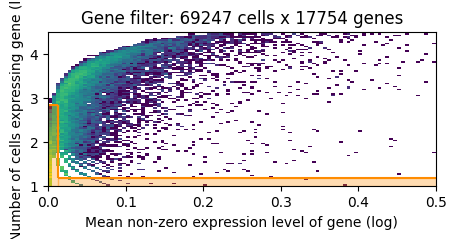

In [6]:
from regularizedvi.utils import filter_genes

selected = filter_genes(
    adata,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.01,
    nonz_mean_cutoff=1.03,
)

In [ ]:
sc.pp.scrublet(
    adata[:, selected],
    batch_key="batch",
    n_prin_comps=40,
    verbose=False,
)

plt.hist(adata.obs["doublet_score"], bins=50)
plt.xlabel("Scrublet score")
plt.title("Doublet scores")
plt.show()

print(f"Fraction above 0.18 threshold: {(adata.obs['doublet_score'] > 0.18).mean():.3f}")

In [ ]:
# Cell filtering
n_before = adata.n_obs
adata = adata[
    (adata.obs["GEX_n_genes"] > 500)
    & (adata.obs["GEX_n_counts"] > 1000)
    & (adata.obs["GEX_n_counts"] < 80000)
    & (adata.obs["GEX_n_genes"] < 10000)
    & (adata.obs["ATAC_atac_fragments"] > 1000)
    & (adata.obs["ATAC_atac_fragments"] < 100000)
    & (adata.obs["mt_frac"] < 0.20)
    & (adata.obs["doublet_score"] < 0.18),
    :,
]
print(f"Filtered {n_before} → {adata.n_obs} cells ({n_before - adata.n_obs} removed)")

## 3. Gene filtering

Recompute gene selection on the filtered cells — cell composition affects detection rates, so we re-run `filter_genes` after QC filtering.

In [ ]:
selected = filter_genes(
    adata,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.01,
    nonz_mean_cutoff=1.03,
)
adata = adata[:, selected].copy()

print(f"Selected {adata.n_vars} genes")

## 4. Model setup and training

### Setup anndata

Standard scVI setup with `batch_key` and `categorical_covariate_keys` matching the regularizedvi tutorial.

In [ ]:
adata.layers["counts"] = adata.X

scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="batch",
    categorical_covariate_keys=["site", "donor"],
)

### Create model

Standard scVI with all default hyperparameters:
- `n_hidden=128`, `n_latent=10`, `n_layers=1`
- `gene_likelihood="zinb"` (zero-inflated NB)
- `dispersion="gene"` (per-gene, not per-batch)
- Observed library size (not learned)
- No ambient RNA correction
- No dispersion regularisation
- Batch info in decoder

In [ ]:
model = scvi.model.SCVI(adata)

### Train

Using scVI's default training settings for a fair comparison of defaults.

In [ ]:
model.train()

### Training loss

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model.history_["elbo_train"][80:])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_title("ELBO (training)")

axes[1].plot(model.history_["reconstruction_loss_train"][80:])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Reconstruction loss")
axes[1].set_title("Reconstruction loss (training)")

plt.tight_layout()
plt.show()

### Save model

In [ ]:
ref_run_name = f"{results_folder}/model"

model.save(ref_run_name, overwrite=True)

## 5. Latent space and visualisation

In [ ]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent

print(f"Latent representation shape: {latent.shape}")

In [ ]:
# Compute KNN and UMAP
k = 50
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=k, metric="euclidean")
sc.tl.umap(adata, min_dist=0.4, spread=1.3)
sc.tl.leiden(adata, resolution=12, flavor="igraph")

In [ ]:
# UMAP coloured by batch, site, and cell type annotations
color = ["site", "batch", "l1_cell_type", "l2_cell_type"]

rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color=color,
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=3,
    vmin=0,
    vmax="p99.9",
    gene_symbols="SYMBOL",
    use_raw=False,
    legend_fontsize=10,
)

In [ ]:
# Leiden clusters
rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color="leiden",
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=3,
    legend_fontsize=10,
)

## 6. Marker gene visualisation

Normalise marker genes per cell (counts per 10k) and overlay on UMAP to verify that the latent space captures expected biology.

In [ ]:
markers = {
    "HSC": ["CD34", "SMIM24"],
    "Erythroid": ["HBZ", "HBA1"],
    "T/ILC": ["CD3D"],
    "NK": ["NKG7"],
    "Myeloid": ["CD14", "CSF1"],
    "DC": ["CD1C"],
    "B/Plasma": ["PTPRC"],
    "Cytotoxic": ["GZMB"],
}

for group_name, gene_list in markers.items():
    # Filter to genes present in the data
    present = [g for g in gene_list if g in adata.var["SYMBOL"].values]
    if not present:
        continue

    # Normalise: counts per 10k
    gene_idx = adata.var["SYMBOL"].isin(present)
    selected_expr = adata[:, gene_idx].X.multiply(1.0 / adata.obs[["GEX_n_counts"]].values)
    selected_expr = selected_expr.toarray() * 1e4

    col_names = [f"{m} normalised" for m in present]
    adata.obs[col_names] = selected_expr

    sc.pl.umap(
        adata,
        color=col_names,
        color_map="RdPu",
        ncols=len(col_names),
        size=3,
        vmin=0,
        vmax="p99.99",
        gene_symbols="SYMBOL",
        use_raw=False,
        legend_fontsize=10,
        title=[f"{group_name}: {m}" for m in present],
    )

## 7. Save outputs

In [ ]:
output_dir = f"{ref_run_name}/outputs/"
os.makedirs(output_dir, exist_ok=True)

# Save latent representation
X_scVI = pd.DataFrame(
    adata.obsm["X_scVI"],
    index=adata.obs_names,
    columns=range(adata.obsm["X_scVI"].shape[1]),
)
X_scVI.to_csv(f"{output_dir}/X_scVI.csv")

# Save UMAP coordinates
X_umap = pd.DataFrame(
    adata.obsm["X_umap"],
    index=adata.obs_names,
    columns=range(2),
)
X_umap.to_csv(f"{output_dir}/X_umap_k{k}.csv")

# Save leiden clustering
adata.obs[["leiden"]].to_csv(f"{output_dir}/leiden_k{k}.csv")

# Save KNN graph
scipy.sparse.save_npz(
    f"{output_dir}/distances_euclidean_k{k}.npz",
    adata.obsp["distances"],
    compressed=True,
)
scipy.sparse.save_npz(
    f"{output_dir}/connectivities_euclidean_k{k}.npz",
    adata.obsp["connectivities"],
    compressed=True,
)

print(f"Outputs saved to {output_dir}")

## Summary

This notebook used standard scVI with all default hyperparameters (`n_hidden=128`, `n_latent=10`, `gene_likelihood="zinb"`). Compare the UMAP and marker gene plots with the other notebooks to see the impact of the regularizedvi modifications and larger architecture.